# WiFi presence detection - data loading and prep

Using the UCI Occupancy Detection dataset. Goal is to load it, clean it, cut it into windows and split into train/val/test for the anomaly detection models.

## Load the dataset

In [1]:
from ucimlrepo import fetch_ucirepo

occupancy = fetch_ucirepo(id=357)

X = occupancy.data.features
y = occupancy.data.targets

print("Features shape:", X.shape)
print("Columns:", X.columns.tolist())
print(X.head())
print(y['Occupancy'].value_counts())

Features shape: (20562, 6)
Columns: ['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
                  date Temperature Humidity  Light     CO2  \
0  2015-02-04 17:51:00       23.18   27.272    426  721.25   
1  2015-02-04 17:51:59       23.15  27.2675  429.5     714   
2  2015-02-04 17:53:00       23.15   27.245    426   713.5   
3  2015-02-04 17:54:00       23.15     27.2    426  708.25   
4  2015-02-04 17:55:00        23.1     27.2    426   704.5   

         HumidityRatio  
0  0.00479298817650529  
1  0.00478344094931065  
2  0.00477946352442199  
3  0.00477150882608175  
4  0.00475699293331518  
Occupancy
0.0    15810
1.0     4750
Name: count, dtype: int64


## Check the types

Quickly looking at what the columns actually contain before doing anything.

In [2]:
print(X.dtypes)
print(X.head(3))
print(X['date'].head(10).tolist())

date             str
Temperature      str
Humidity         str
Light            str
CO2              str
HumidityRatio    str
dtype: object
                  date Temperature Humidity  Light     CO2  \
0  2015-02-04 17:51:00       23.18   27.272    426  721.25   
1  2015-02-04 17:51:59       23.15  27.2675  429.5     714   
2  2015-02-04 17:53:00       23.15   27.245    426   713.5   

         HumidityRatio  
0  0.00479298817650529  
1  0.00478344094931065  
2  0.00477946352442199  
['2015-02-04 17:51:00', '2015-02-04 17:51:59', '2015-02-04 17:53:00', '2015-02-04 17:54:00', '2015-02-04 17:55:00', '2015-02-04 17:55:59', '2015-02-04 17:57:00', '2015-02-04 17:57:59', '2015-02-04 17:58:59', '2015-02-04 18:00:00']


## Clean and fix types

Everything loaded as string. Also found 2 rows where a header got mixed into the data (the date column literally says "Temperature"). This is because UCI ships 3 files stitched together. Removing those rows then converting types.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = X.copy()
df['Occupancy'] = y['Occupancy'].values

# drop the broken header rows
bad_mask = df['date'].astype(str).str.contains('Temperature|date|Date', na=False)
print("removing", bad_mask.sum(), "bad rows")
df = df[~bad_mask].reset_index(drop=True)

df['date'] = pd.to_datetime(df['date'])
signal_cols = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
df[signal_cols] = df[signal_cols].astype(float)
df['Occupancy'] = df['Occupancy'].astype(int)

df = df.sort_values('date').reset_index(drop=True)

print("shape:", df.shape)
print("date range:", df['date'].min(), "->", df['date'].max())
print(df.dtypes)
print(df['Occupancy'].value_counts())
print("nulls:", df.isnull().sum().sum())

removing 2 bad rows
shape: (20560, 7)
date range: 2015-02-02 14:19:00 -> 2015-02-18 09:19:00
date             datetime64[us]
Temperature             float64
Humidity                float64
Light                   float64
CO2                     float64
HumidityRatio           float64
Occupancy                 int64
dtype: object
Occupancy
0    15810
1     4750
Name: count, dtype: int64
nulls: 0


## Plot the signals

Just want to see if occupancy is actually visible in the signals before building anything.

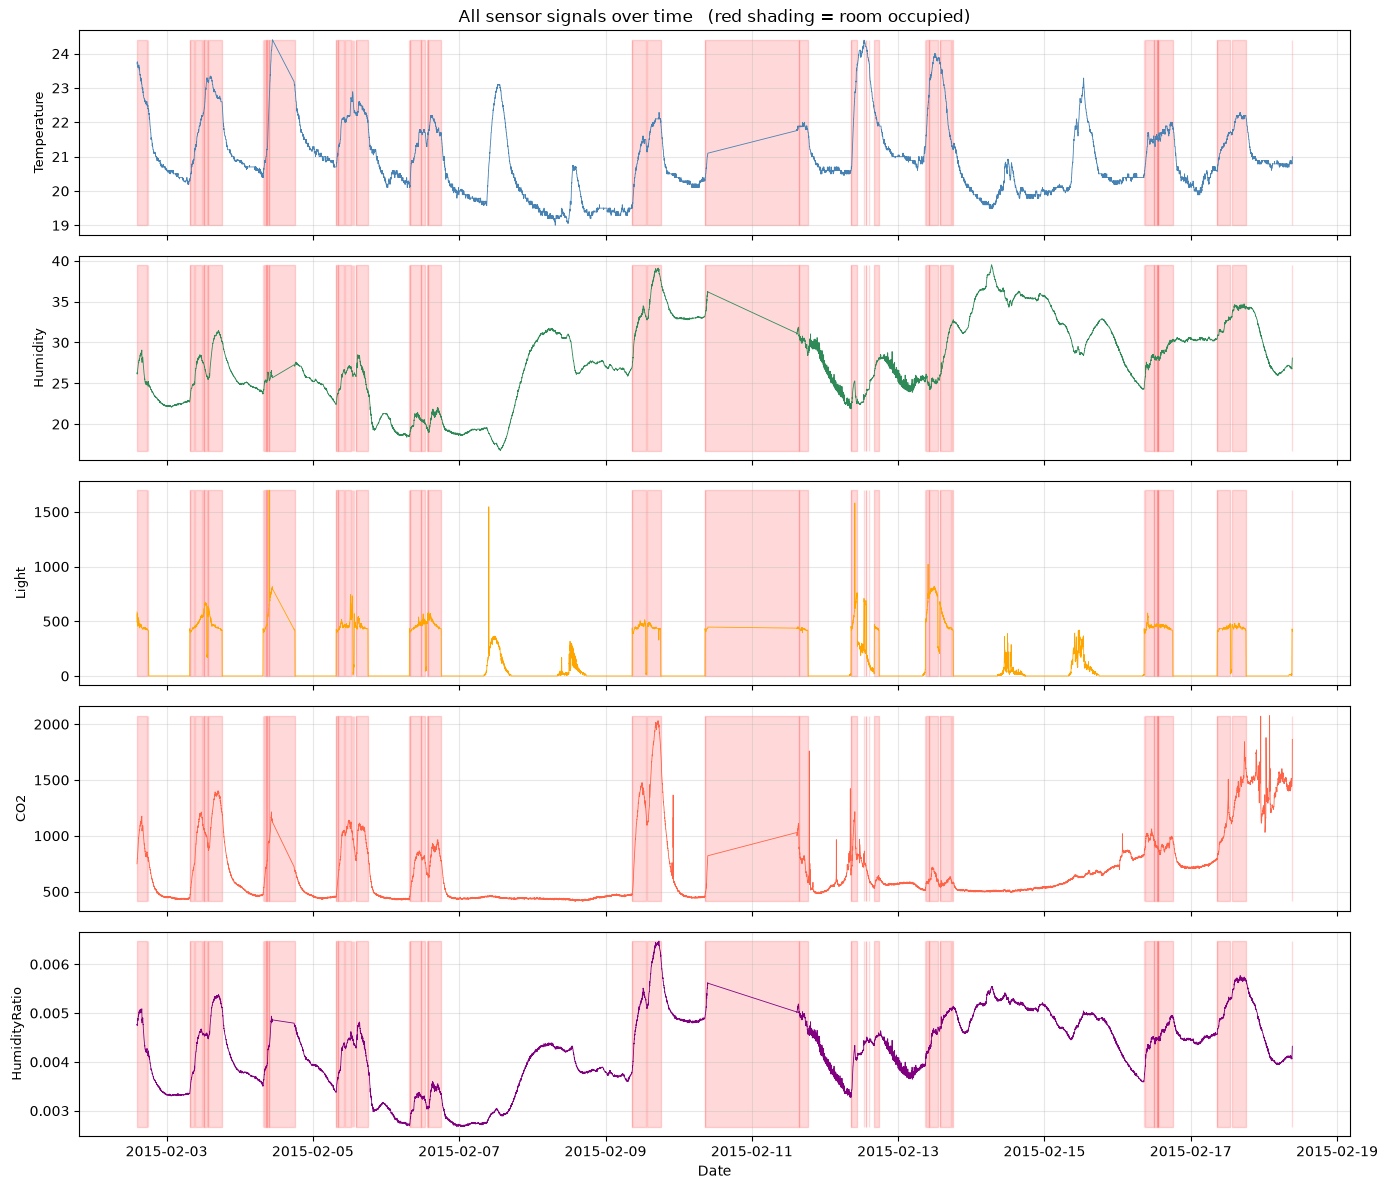

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

signals = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
colors  = ['steelblue', 'seagreen', 'orange', 'tomato', 'purple']

for ax, signal, color in zip(axes, signals, colors):
    ax.plot(df['date'], df[signal], color=color, linewidth=0.6)
    ax.set_ylabel(signal, fontsize=9)
    ax.grid(True, alpha=0.3)
    ymin, ymax = df[signal].min(), df[signal].max()
    ax.fill_between(df['date'], ymin, ymax, where=df['Occupancy'] == 1,
                    alpha=0.15, color='red')

axes[0].set_title('All sensor signals over time   (red shading = room occupied)')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../results/01_signals_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## What I see in the plot

Red bands = room occupied.

- Light is the clearest one, near zero when empty, jumps to 400-800 when occupied
- CO2 also goes up when occupied since people breathe out CO2, but it reacts slower and falls down gradually after people leave
- Temperature goes up a bit (body heat) but weaker and noisier
- Humidity and HumidityRatio barely react

The straight diagonal lines around Feb 11 are gaps where the sensor stopped recording.

Main point is the occupied vs empty difference is clearly visible by eye especially in Light and CO2, so the signal should be learnable.

## Cut into windows

A single row is just one minute, not enough context. So I cut the signal into 30 minute windows and each window becomes one sample. Using only Light and CO2 since those are the strongest. Window is 30 (one row per minute), stride 5 so they overlap a bit but not too much.

A window is labeled occupied if anyone was present during any minute of it.

In [5]:
import numpy as np

SIGNALS = ['Light', 'CO2']
WINDOW_SIZE = 30
STRIDE = 5

def make_windows(df, signals, window_size, stride):
    data = df[signals].values
    occ  = df['Occupancy'].values
    windows, labels = [], []
    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        windows.append(data[start:end])
        labels.append(int(occ[start:end].any()))
    return np.array(windows), np.array(labels)

windows, labels = make_windows(df, SIGNALS, WINDOW_SIZE, STRIDE)

print("windows:", windows.shape)
print("labels:", labels.shape)
print("empty:", (labels == 0).sum(), " occupied:", (labels == 1).sum())

windows: (4107, 30, 2)
labels: (4107,)
empty: 3008  occupied: 1099


## Train / val / test split

Setup is unsupervised. Train and val only see empty windows so the model learns what normal looks like. Test has both empty and occupied so I can measure if it detects presence.

Splitting by time not randomly. Windows overlap so a random split would leak shared minutes between train and test which is cheating. So first 70% of empty windows go to train, next 15% val, last 15% test. All occupied windows go to test.

In [6]:
empty_idx    = np.where(labels == 0)[0]
occupied_idx = np.where(labels == 1)[0]

n_empty = len(empty_idx)
train_end = int(0.70 * n_empty)
val_end   = int(0.85 * n_empty)

train_empty_idx = empty_idx[:train_end]
val_empty_idx   = empty_idx[train_end:val_end]
test_empty_idx  = empty_idx[val_end:]

X_train = windows[train_empty_idx]
X_val   = windows[val_empty_idx]

test_idx = np.sort(np.concatenate([test_empty_idx, occupied_idx]))
X_test = windows[test_idx]
y_test = labels[test_idx]

print("X_train (empty):", X_train.shape)
print("X_val   (empty):", X_val.shape)
print("X_test  (mixed):", X_test.shape)
print("test empty:", (y_test == 0).sum(), " test occupied:", (y_test == 1).sum())

X_train (empty): (2105, 30, 2)
X_val   (empty): (451, 30, 2)
X_test  (mixed): (1551, 30, 2)
test empty: 452  test occupied: 1099


## Normalize

Light and CO2 are on totally different scales (Light 0-1600, CO2 400-2000) so I z-score normalize them. Important part: mean and std come from train only, then applied to val and test, otherwise it leaks test info.

In [7]:
train_mean = X_train.mean(axis=(0, 1))
train_std  = X_train.std(axis=(0, 1))

print("mean [Light, CO2]:", train_mean)
print("std  [Light, CO2]:", train_std)

def normalize(x, mean, std):
    return (x - mean) / (std + 1e-8)

X_train_norm = normalize(X_train, train_mean, train_std)
X_val_norm   = normalize(X_val,   train_mean, train_std)
X_test_norm  = normalize(X_test,  train_mean, train_std)

print("train mean after norm:", X_train_norm.mean(axis=(0,1)))
print("train std after norm:", X_train_norm.std(axis=(0,1)))
print(X_train_norm.shape, X_val_norm.shape, X_test_norm.shape)

mean [Light, CO2]: [ 15.99397836 505.05285869]
std  [Light, CO2]: [ 61.83015042 119.97928703]
train mean after norm: [1.83267952e-14 4.21712022e-14]
train std after norm: [1. 1.]
(2105, 30, 2) (451, 30, 2) (1551, 30, 2)


In [8]:
import numpy as np

np.savez('../data/prepared.npz',
         X_train=X_train, X_val=X_val, X_test=X_test, y_test=y_test,
         train_mean=train_mean, train_std=train_std)
print("saved prepared.npz")

saved prepared.npz
